- DSC 530
- Week 7 and 8
- Rethish Plappuzha Sreedharan Nair

In [100]:
# importing the required modules
import pandas as pd
import numpy as np

# Chapter 5

## Exercise 1.

Plot the rolling 20-day minimum of the Facebook closing price using pandas.

In [101]:
# Reading the CSV file into a DataFrame and setting the index column as 'Date'
df_db = pd.read_csv('fb_stock_prices_2018.csv', index_col='date', parse_dates=True)
df_db.head()

,open,high,low,close,volume
date,,,,,
2018-01-02,177.68,181.58,177.5500,181.42,18151903
2018-01-03,181.88,184.78,181.3300,184.67,16886563
2018-01-04,184.90,186.21,184.0996,184.33,13880896
2018-01-05,185.59,186.90,184.9300,186.85,13574535
2018-01-08,187.20,188.90,186.3300,188.28,17994726


<Axes: title={'center': '20 Day Rolling Average of Close Price'}, xlabel='date', ylabel='Price in $'>

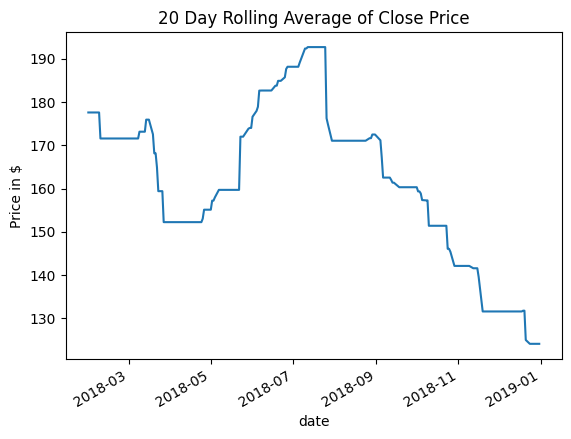

In [102]:
df_db.close.rolling(window=20).min().plot(title='20 Day Rolling Average of Close Price', ylabel='Price in $')

## Exercise 2.

Create a histogram and KDE of the change from open to close in the price of Facebook stock.



<Axes: title={'center': 'Histogram and KDE of Change from Open to Close Price'}, ylabel='Density'>

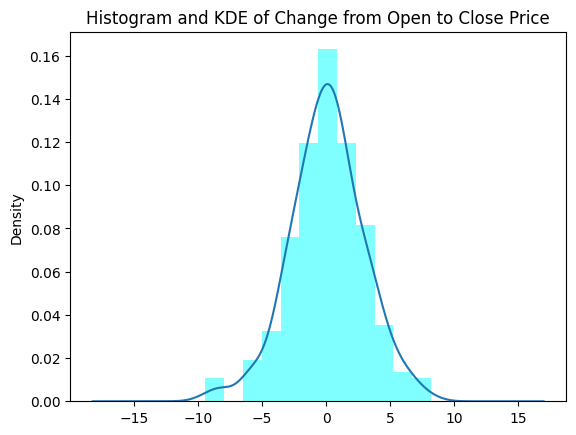

In [103]:
# Creating a new column for the change from open to close price
df_db['change_open_close'] = df_db.close - df_db.open


# Creating a histogram and KDE plot we are passing the 12 bins and density as True to normalize the histogram
df_db.change_open_close.plot.hist(density=True, bins=12, alpha=0.5, color= 'cyan', 
                                  title='Histogram and KDE of Change from Open to Close Price')
df_db.change_open_close.plot.kde()

## Exercise 3.

Using the earthquake data, create box plots for the magnitudes of each magType used in Indonesia.

In [104]:
# Reading the earthquake data CSV file into a DataFrame
df_eq = pd.read_csv('earthquakes.csv')
df_eq.head()

,mag,magType,time,place,tsunami,parsed_place
0,1.35,ml,1539475168010,"9km NE of Aguanga, CA",0,California
1,1.29,ml,1539475129610,"9km NE of Aguanga, CA",0,California
2,3.42,ml,1539475062610,"8km NE of Aguanga, CA",0,California
3,0.44,ml,1539474978070,"9km NE of Aguanga, CA",0,California
4,2.16,md,1539474716050,"10km NW of Avenal, CA",0,California


In [105]:
# Filtering the DataFrame for earthquakes that occurred in Indonesia

df_eq_indonesia = df_eq[df_eq.parsed_place.str.contains('Indonesia')]
df_eq_indonesia.head()

,mag,magType,time,place,tsunami,parsed_place
9,4.7,mb,1539472814760,"219km SSE of Saparua, Indonesia",0,Indonesia
13,4.5,mb,1539470898340,"120km SSW of Banda Aceh, Indonesia",0,Indonesia
180,5.2,mww,1539405255580,"25km E of Bitung, Indonesia",0,Indonesia
421,4.7,mb,1539331098920,"38km SSW of Nggongi Satu, Indonesia",0,Indonesia
660,4.4,mb,1539258833830,"51km WSW of Kasiguncu, Indonesia",0,Indonesia


Text(0.5, 1.0, 'Box Plots of Magnitudes by magType in Indonesia')

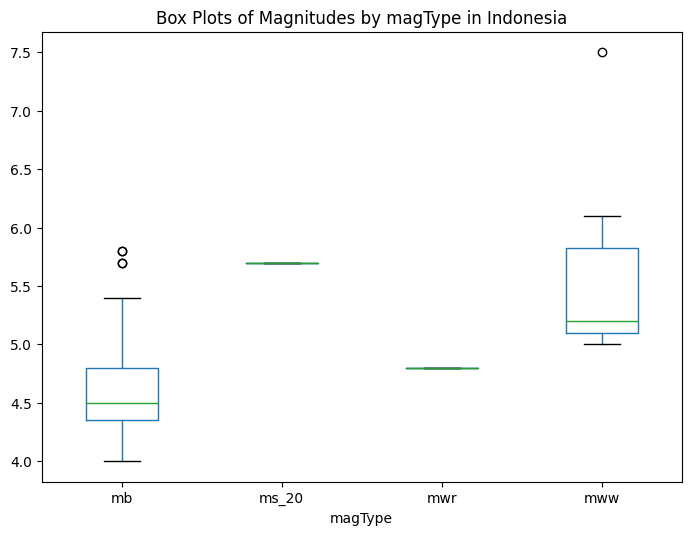

In [106]:
# Using the df_eq_indonesia data, create box plots for the magnitudes of each magType used in Indonesia.
plt=df_eq_indonesia.boxplot(column='mag', by='magType', grid=False, figsize=(8,6))
fig = plt.get_figure()
fig.suptitle('')    # To remove the automatic 'Boxplot grouped by magType' title
plt.set_title('Box Plots of Magnitudes by magType in Indonesia')

## Exercise 4.

Make a line plot of the difference between the weekly maximum high price and the weekly minimum low price for Facebook. This should be a single line.

In [107]:
df_db

,open,high,low,close,volume,change_open_close
date,,,,,,
2018-01-02,177.68,181.58,177.5500,181.42,18151903,3.74
2018-01-03,181.88,184.78,181.3300,184.67,16886563,2.79
2018-01-04,184.90,186.21,184.0996,184.33,13880896,-0.57
2018-01-05,185.59,186.90,184.9300,186.85,13574535,1.26
2018-01-08,187.20,188.90,186.3300,188.28,17994726,1.08
...,...,...,...,...,...,...
2018-12-24,123.10,129.74,123.0200,124.06,22066002,0.96
2018-12-26,126.00,134.24,125.8900,134.18,39723370,8.18
2018-12-27,132.44,134.99,129.6700,134.52,31202509,2.08


<Axes: title={'center': 'Weekly Max High - Weekly Min Low Price'}, xlabel='date', ylabel='Price in $'>

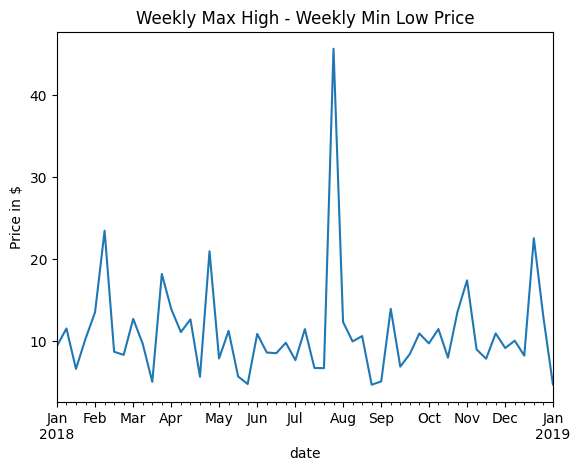

In [108]:
# Resampling the DataFrame to weekly frequency and calculating the difference between the weekly maximum high price and the weekly minimum low price

df_db.resample('W').apply(lambda x: x.high.max() - x.low.min()).plot(title='Weekly Max High - Weekly Min Low Price', 
                                                                     ylabel='Price in $')


# Chapter 6

## Exercise 1.

Using Seaborn, create a heatmap to visualize the correlation coefficients between earthquake magnitude and whether there was a tsunami for earthquakes measured with the mb magnitude type.



In [109]:
# importing seaborn and matplotlib for visualization
import seaborn as sns
import matplotlib.pyplot as plt

In [110]:
# Calculating the correlation coefficients between earthquake magnitude and 
# whether there was a tsunami for earthquakes measured with the mb magnitude type
cor_coeff = df_eq[df_eq.magType == 'mb'][['mag', 'tsunami']].corr()
cor_coeff

,mag,tsunami
mag,1.000000,0.448921
tsunami,0.448921,1.000000


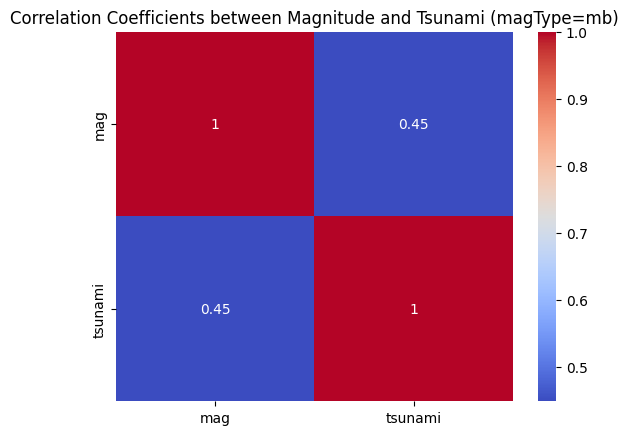

In [111]:
# Creating a heatmap to visualize the correlation coefficients
sns.heatmap(cor_coeff, annot=True, cmap='coolwarm')
plt.title('Correlation Coefficients between Magnitude and Tsunami (magType=mb)')
plt.show()

## Exercise 2.

- Create a box plot of Facebook volume traded and closing prices and draw reference lines for the bounds of a Tukey fence with a multiplier of 1.5. 
- The bounds will be at Q1 − 1.5 × IQR and Q3 + 1.5 × IQR. Be sure to use the quantile() method on the data to make this easier. 
- Pick whichever orientation you prefer for the plot, but make sure to use subplots.

In [112]:
# Calcualting the quartiles and IQR for volume and close price
q1_vol = df_db['volume'].quantile(0.25)
q3_vol = df_db['volume'].quantile(0.75)
IQR_vol=q3_vol-q1_vol

print(f"Volume - Q1: {q1_vol}, Q3: {q3_vol}, IQR: {IQR_vol}")

q1_close = df_db['close'].quantile(0.25)
q3_close = df_db['close'].quantile(0.75)
IQR_close=q3_close - q1_close
print(f"Close Price - Q1: {q1_close}, Q3: {q3_close}, IQR: {IQR_close}")

Volume - Q1: 17828394.0, Q3: 30313840.0, IQR: 12485446.0
Close Price - Q1: 157.91500000000002, Q3: 185.26999999999998, IQR: 27.35499999999996


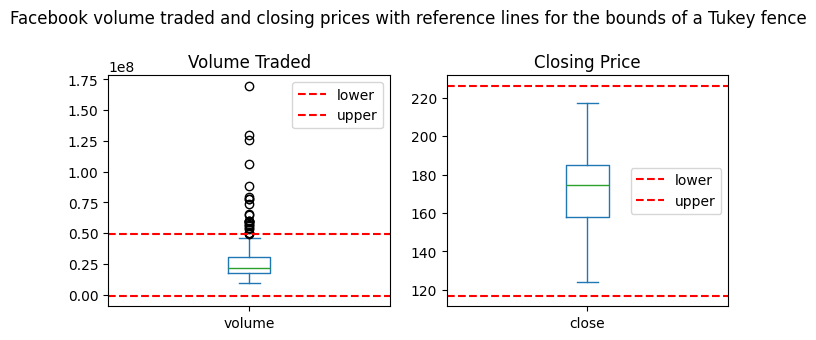

In [113]:
plots  = df_db[['volume', 'close']].plot(kind='box', subplots=True, figsize=(8, 3), title=['Volume Traded', 'Closing Price'])
plt.suptitle("Facebook volume traded and closing prices with reference lines for the bounds of a Tukey fence",y=1.1)

# Calculating the Tukey fence bounds
lower_vol = q1_vol - 1.5 * IQR_vol
upper_vol = q3_vol + 1.5 * IQR_vol
lower_close = q1_close - 1.5 * IQR_close
upper_close = q3_close + 1.5 * IQR_close

# Adding horizontal lines to indicate the Tukey fence bounds
plots['volume'].axhline(lower_vol,color='red',linestyle='dashed',label='lower')
plots['volume'].axhline(upper_vol,color='red',linestyle='dashed',label='upper')
plots['volume'].legend()

# Adding horizontal lines to indicate the Tukey fence bounds
plots['close'].axhline(lower_close,color='red',linestyle='dashed',label='lower')
plots['close'].axhline(upper_close,color='red',linestyle='dashed',label='upper')
plots['close'].legend()
